In [1]:
import os
import shutil
import glob
import yaml
from pathlib import Path

# Source dataset
SRC_BASE = '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset'
SRC_SPLITS = {
    'train': f'{SRC_BASE}/VisDrone2019-DET-train',
    'val':   f'{SRC_BASE}/VisDrone2019-DET-val',
    'test':  f'{SRC_BASE}/VisDrone2019-DET-test-dev',
}

# Output dataset (writable area)
OUT_BASE = '/kaggle/working/visdrone_processed'

# Class mapping: Original → New
# Original: 0=Pedestrian, 1=People, 3=Car
# New:      0=Human (merged Ped+People), 1=Car
ORIGINAL_TO_NEW = {
    0: 0,  # Pedestrian → Human
    1: 0,  # People → Human
    3: 1,  # Car → Car
}
NEW_CLASS_NAMES = {0: 'Human', 1: 'Car'}
TARGET_ORIGINAL_IDS = set(ORIGINAL_TO_NEW.keys())

print("✅ Preprocessing config ready")
print(f"   Mapping: Pedestrian(0)→Human(0), People(1)→Human(0), Car(3)→Car(1)")
print(f"   Output: {OUT_BASE}")


# Preprocessing — Remap Labels & Copy Images

stats = {}

for split_name, src_path in SRC_SPLITS.items():
    src_img_dir = os.path.join(src_path, 'images')
    src_lbl_dir = os.path.join(src_path, 'labels')

    out_img_dir = os.path.join(OUT_BASE, 'images', split_name)
    out_lbl_dir = os.path.join(OUT_BASE, 'labels', split_name)
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)

    total_images = 0
    total_kept = 0
    total_dropped = 0
    images_with_targets = 0
    empty_after_filter = 0

    lbl_files = sorted(glob.glob(os.path.join(src_lbl_dir, '*.txt')))

    for lbl_file in lbl_files:
        stem = Path(lbl_file).stem
        src_img = os.path.join(src_img_dir, f'{stem}.jpg')

        if not os.path.exists(src_img):
            continue

        total_images += 1

        # Read and remap labels
        new_lines = []
        with open(lbl_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id = int(parts[0])
                if cls_id in TARGET_ORIGINAL_IDS:
                    new_cls = ORIGINAL_TO_NEW[cls_id]
                    new_lines.append(f"{new_cls} {' '.join(parts[1:5])}\n")
                    total_kept += 1
                else:
                    total_dropped += 1

        # Write new label file (even if empty — keeps background images)
        out_lbl_file = os.path.join(out_lbl_dir, f'{stem}.txt')
        with open(out_lbl_file, 'w') as f:
            f.writelines(new_lines)

        if new_lines:
            images_with_targets += 1
        else:
            empty_after_filter += 1

        # Symlink image (saves disk space) — fallback to copy
        out_img = os.path.join(out_img_dir, f'{stem}.jpg')
        try:
            os.symlink(src_img, out_img)
        except (OSError, NotImplementedError):
            shutil.copy2(src_img, out_img)

    stats[split_name] = {
        'images': total_images,
        'kept': total_kept,
        'dropped': total_dropped,
        'with_targets': images_with_targets,
        'empty': empty_after_filter
    }

    print(f"\n✅ {split_name.upper()}: {total_images} images processed")
    print(f"   Annotations kept:    {total_kept:>7,}")
    print(f"   Annotations dropped: {total_dropped:>7,}")
    print(f"   Images with targets: {images_with_targets}")
    print(f"   Background images:   {empty_after_filter}")

print(f"\nOutput saved to: {OUT_BASE}")



# Preprocessing — Create data.yaml
data_yaml = {
    'path': OUT_BASE,
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': 2,
    'names': ['Human', 'Car']
}

yaml_path = os.path.join(OUT_BASE, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

print("✅ data.yaml created:")
print(f"   Path: {yaml_path}")
print(f"\n   Contents:")
with open(yaml_path, 'r') as f:
    print(f.read())


# Preprocessing — Verify Processed Dataset

for split_name in ['train', 'val', 'test']:
    img_dir = os.path.join(OUT_BASE, 'images', split_name)
    lbl_dir = os.path.join(OUT_BASE, 'labels', split_name)

    imgs = glob.glob(os.path.join(img_dir, '*.jpg'))
    lbls = glob.glob(os.path.join(lbl_dir, '*.txt'))

    # Count annotations per class
    class_counts = {0: 0, 1: 0}
    for lbl_file in lbls:
        with open(lbl_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    cls = int(parts[0])
                    class_counts[cls] = class_counts.get(cls, 0) + 1

    total = sum(class_counts.values())
    print(f"\n{split_name.upper()}:")
    print(f"  Images: {len(imgs)}")
    print(f"  Labels: {len(lbls)}")
    print(f"  Human (cls 0): {class_counts.get(0, 0):>7,} ({class_counts.get(0,0)/max(total,1)*100:.1f}%)")
    print(f"  Car   (cls 1): {class_counts.get(1, 0):>7,} ({class_counts.get(1,0)/max(total,1)*100:.1f}%)")
    print(f"  Total:         {total:>7,}")

    # Verify a random label file
    import random
    sample_lbl = random.choice(lbls)
    with open(sample_lbl, 'r') as f:
        content = f.read()
    print(f"\n  Sample label ({Path(sample_lbl).name}):")
    for line in content.strip().split('\n')[:5]:
        print(f"    {line}")

print("\n✅ Dataset ready for training!")


✅ Preprocessing config ready
   Mapping: Pedestrian(0)→Human(0), People(1)→Human(0), Car(3)→Car(1)
   Output: /kaggle/working/visdrone_processed

✅ TRAIN: 6471 images processed
   Annotations kept:    251,263
   Annotations dropped:  91,942
   Images with targets: 6468
   Background images:   3

✅ VAL: 548 images processed
   Annotations kept:     28,033
   Annotations dropped:  10,726
   Images with targets: 548
   Background images:   0

✅ TEST: 1610 images processed
   Annotations kept:     55,456
   Annotations dropped:  19,646
   Images with targets: 1603
   Background images:   7

Output saved to: /kaggle/working/visdrone_processed
✅ data.yaml created:
   Path: /kaggle/working/visdrone_processed/data.yaml

   Contents:
path: /kaggle/working/visdrone_processed
train: images/train
val: images/val
test: images/test
nc: 2
names:
- Human
- Car


TRAIN:
  Images: 6471
  Labels: 6471
  Human (cls 0): 106,396 (42.3%)
  Car   (cls 1): 144,867 (57.7%)
  Total:         251,263

  Sample lab

In [5]:
# Install Ultralytics & Setup
!pip install -q ultralytics

import torch
from ultralytics import YOLO

from IPython.display import Image, display
import os

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.1 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.6 GB


In [6]:
DATA_YAML = '/kaggle/working/visdrone_processed/data.yaml'

In [7]:
import os

yaml_content = """# YOLOv11m-P2: YOLO11 with P2/4 detection head for small objects
# Adapted from ultralytics yolo11.yaml + yolov8-p2.yaml pattern
# Architecture: P2/4 - P5/32 outputs (4 detection heads)

# Parameters
nc: 2  # Human, Car
scales:
  m: [0.50, 1.00, 512]  # YOLOv11m scaling

# YOLO11 backbone (IDENTICAL to standard yolo11.yaml)
backbone:
  # [from, repeats, module, args]
  - [-1, 1, Conv, [64, 3, 2]]         # 0  - P1/2
  - [-1, 1, Conv, [128, 3, 2]]        # 1  - P2/4
  - [-1, 2, C3k2, [256, False, 0.25]] # 2  - P2 features ← WE TAP HERE
  - [-1, 1, Conv, [256, 3, 2]]        # 3  - P3/8
  - [-1, 2, C3k2, [512, False, 0.25]] # 4  - P3 features
  - [-1, 1, Conv, [512, 3, 2]]        # 5  - P4/16
  - [-1, 2, C3k2, [512, True]]        # 6  - P4 features
  - [-1, 1, Conv, [1024, 3, 2]]       # 7  - P5/32
  - [-1, 2, C3k2, [1024, True]]       # 8
  - [-1, 1, SPPF, [1024, 5]]          # 9
  - [-1, 2, C2PSA, [1024]]            # 10 - P5 features (backbone output)

# YOLO11-P2 head (modified to include P2 detection)
head:
  # ---- Top-Down Path (FPN) ----

  # P5 → P4 fusion
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]  # 11 - upsample P5
  - [[-1, 6], 1, Concat, [1]]                    # 12 - cat with backbone P4
  - [-1, 2, C3k2, [512, False]]                  # 13 - P4 neck block

  # P4 → P3 fusion
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]  # 14 - upsample P4
  - [[-1, 4], 1, Concat, [1]]                    # 15 - cat with backbone P3
  - [-1, 2, C3k2, [256, False]]                  # 16 - P3 neck block

  # P3 → P2 fusion (NEW — the P2 branch)
  - [-1, 1, nn.Upsample, [None, 2, "nearest"]]  # 17 - upsample P3
  - [[-1, 2], 1, Concat, [1]]                    # 18 - cat with backbone P2 (layer 2)
  - [-1, 2, C3k2, [128, False]]                  # 19 - P2 neck block (P2/4-xsmall) ⭐

  # ---- Bottom-Up Path (PAN) ----

  # P2 → P3 downsample
  - [-1, 1, Conv, [128, 3, 2]]                   # 20 - downsample P2
  - [[-1, 16], 1, Concat, [1]]                   # 21 - cat with P3 neck (layer 16)
  - [-1, 2, C3k2, [256, False]]                  # 22 - P3 PAN block (P3/8-small)

  # P3 → P4 downsample
  - [-1, 1, Conv, [256, 3, 2]]                   # 23 - downsample P3
  - [[-1, 13], 1, Concat, [1]]                   # 24 - cat with P4 neck (layer 13)
  - [-1, 2, C3k2, [512, False]]                  # 25 - P4 PAN block (P4/16-medium)

  # P4 → P5 downsample
  - [-1, 1, Conv, [512, 3, 2]]                   # 26 - downsample P4
  - [[-1, 10], 1, Concat, [1]]                   # 27 - cat with backbone P5 (layer 10)
  - [-1, 2, C3k2, [1024, True]]                  # 28 - P5 PAN block (P5/32-large)

  # ---- Detection ----
  - [[19, 22, 25, 28], 1, Detect, [nc]]          # 29 - Detect(P2, P3, P4, P5)
"""

# Write YAML to Kaggle working directory
yaml_path = '/kaggle/working/yolo11m-p2.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"✅ Custom YAML written to: {yaml_path}")
print(f"   File size: {os.path.getsize(yaml_path)} bytes")

# Print the YAML for verification
print("\n📄 Architecture YAML:")
print("=" * 60)
print(yaml_content)

✅ Custom YAML written to: /kaggle/working/yolo11m-p2.yaml
   File size: 2754 bytes

📄 Architecture YAML:
# YOLOv11m-P2: YOLO11 with P2/4 detection head for small objects
# Adapted from ultralytics yolo11.yaml + yolov8-p2.yaml pattern
# Architecture: P2/4 - P5/32 outputs (4 detection heads)

# Parameters
nc: 2  # Human, Car
scales:
  m: [0.50, 1.00, 512]  # YOLOv11m scaling

# YOLO11 backbone (IDENTICAL to standard yolo11.yaml)
backbone:
  # [from, repeats, module, args]
  - [-1, 1, Conv, [64, 3, 2]]         # 0  - P1/2
  - [-1, 1, Conv, [128, 3, 2]]        # 1  - P2/4
  - [-1, 2, C3k2, [256, False, 0.25]] # 2  - P2 features ← WE TAP HERE
  - [-1, 1, Conv, [256, 3, 2]]        # 3  - P3/8
  - [-1, 2, C3k2, [512, False, 0.25]] # 4  - P3 features
  - [-1, 1, Conv, [512, 3, 2]]        # 5  - P4/16
  - [-1, 2, C3k2, [512, True]]        # 6  - P4 features
  - [-1, 1, Conv, [1024, 3, 2]]       # 7  - P5/32
  - [-1, 2, C3k2, [1024, True]]       # 8
  - [-1, 1, SPPF, [1024, 5]]          # 9
  - 

In [8]:
from ultralytics import YOLO
import torch

yaml_path = '/kaggle/working/yolo11m-p2.yaml'

# Step 1: Build model from custom YAML
print("🔨 Building model from custom YAML...")
model_p2 = YOLO(yaml_path)
print("✅ Model built successfully!")

# Step 2: Print model info
print("\n📊 MODEL INFO:")
print("=" * 60)
model_p2.info(detailed=False)

# Step 3: Transfer pretrained weights from yolo11m
print("\n📥 Loading pretrained YOLOv11m weights...")
model_p2 = YOLO(yaml_path).load('yolo11m.pt')
print("✅ Weights transferred (backbone + matching head layers)")

# Step 4: Dummy forward pass to verify shapes
print("\n🧪 Running dummy forward pass...")
dummy_input = torch.randn(1, 3, 1280, 1280).to('cuda' if torch.cuda.is_available() else 'cpu')
model_p2.model.to(dummy_input.device)
model_p2.model.eval()

with torch.no_grad():
    try:
        output = model_p2.model(dummy_input)
        print("✅ Forward pass successful!")
        if isinstance(output, (list, tuple)):
            for i, o in enumerate(output):
                if hasattr(o, 'shape'):
                    print(f"   Output {i}: {o.shape}")
        else:
            print(f"   Output shape: {output.shape}")
    except Exception as e:
        print(f"❌ Forward pass failed: {e}")
        print("   Check YAML layer indices and channel dimensions!")

# Step 5: Compare parameter counts
model_std = YOLO('yolo11m.pt')
p2_params = sum(p.numel() for p in model_p2.model.parameters())
std_params = sum(p.numel() for p in model_std.model.parameters())
print(f"\n📊 Parameter Comparison:")
print(f"   Standard YOLOv11m: {std_params:,} params ({std_params/1e6:.1f}M)")
print(f"   YOLOv11m-P2:      {p2_params:,} params ({p2_params/1e6:.1f}M)")
print(f"   Overhead:          +{(p2_params-std_params):,} params (+{(p2_params-std_params)/std_params*100:.1f}%)")

del dummy_input, model_std
torch.cuda.empty_cache()

print("\n✅ Architecture verified — ready for training!")

🔨 Building model from custom YAML...
✅ Model built successfully!

📊 MODEL INFO:
YOLO11m-p2 summary: 287 layers, 20,550,872 parameters, 20,550,856 gradients, 88.3 GFLOPs

📥 Loading pretrained YOLOv11m weights...
Transferred 427/803 items from pretrained weights
✅ Weights transferred (backbone + matching head layers)

🧪 Running dummy forward pass...
✅ Forward pass successful!
   Output 0: torch.Size([1, 6, 136000])

📊 Parameter Comparison:
   Standard YOLOv11m: 20,114,688 params (20.1M)
   YOLOv11m-P2:      20,550,872 params (20.6M)
   Overhead:          +436,184 params (+2.2%)

✅ Architecture verified — ready for training!


In [ ]:
from ultralytics import YOLO

yaml_path = '/kaggle/working/yolo11m-p2.yaml'
DATA_YAML = '/kaggle/working/visdrone_processed/data.yaml'

# Load architecture + transfer pretrained weights
model_p2 = YOLO('/kaggle/working/runs/p2_head_1280/weights/last.pt')

results_p2 = model_p2.train(
    data=DATA_YAML,
    epochs=75,
    imgsz=1280,
    batch=2,                # reduced for P2 memory overhead
    optimizer='AdamW',
    lr0=0.001,              # slightly higher LR — new P2 head needs to learn
    lrf=0.01,
    warmup_epochs=5,
    patience=20,
    augment=True,
    mosaic=1.0,
    mixup=0.15,
    scale=0.5,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5.0,
    translate=0.1,
    project='/kaggle/working/runs',
    name='p2_head_1280',
    save=True,
    save_period=10,
    plots=True,
    verbose=True,
    workers=4,
    exist_ok=True,
    resume=True
)

print("\n✅ P2 Head training complete!")
print(f"Results saved to: /kaggle/working/runs/p2_head_1280/")

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/visdrone_processed/data.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=/kaggle/working/runs/p2_head_1280/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=p2_head_1280, nbs=64, nms=False, opset=None, op

# **Batch Evaluation on Test Set**

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m-p2 summary (fused): 156 layers, 20,526,744 parameters, 0 gradients, 87.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 115.2±31.0 MB/s, size: 172.6 KB)
val: Scanning /kaggle/working/visdrone_processed/labels/test.cache... 1610 images, 7 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1610/1610 675.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 805/805 5.3it/s 2:33<0.2s
                   all       1610      55456      0.772      0.615       0.57      0.321
                 Human       1267      27382      0.739      0.417      0.376      0.159
                   Car       1530      28074      0.804      0.813      0.763      0.483
Speed: 1.9ms preprocess, 87.1ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /kaggle/working/runs/test_evaluation

confusion_matrix.png:


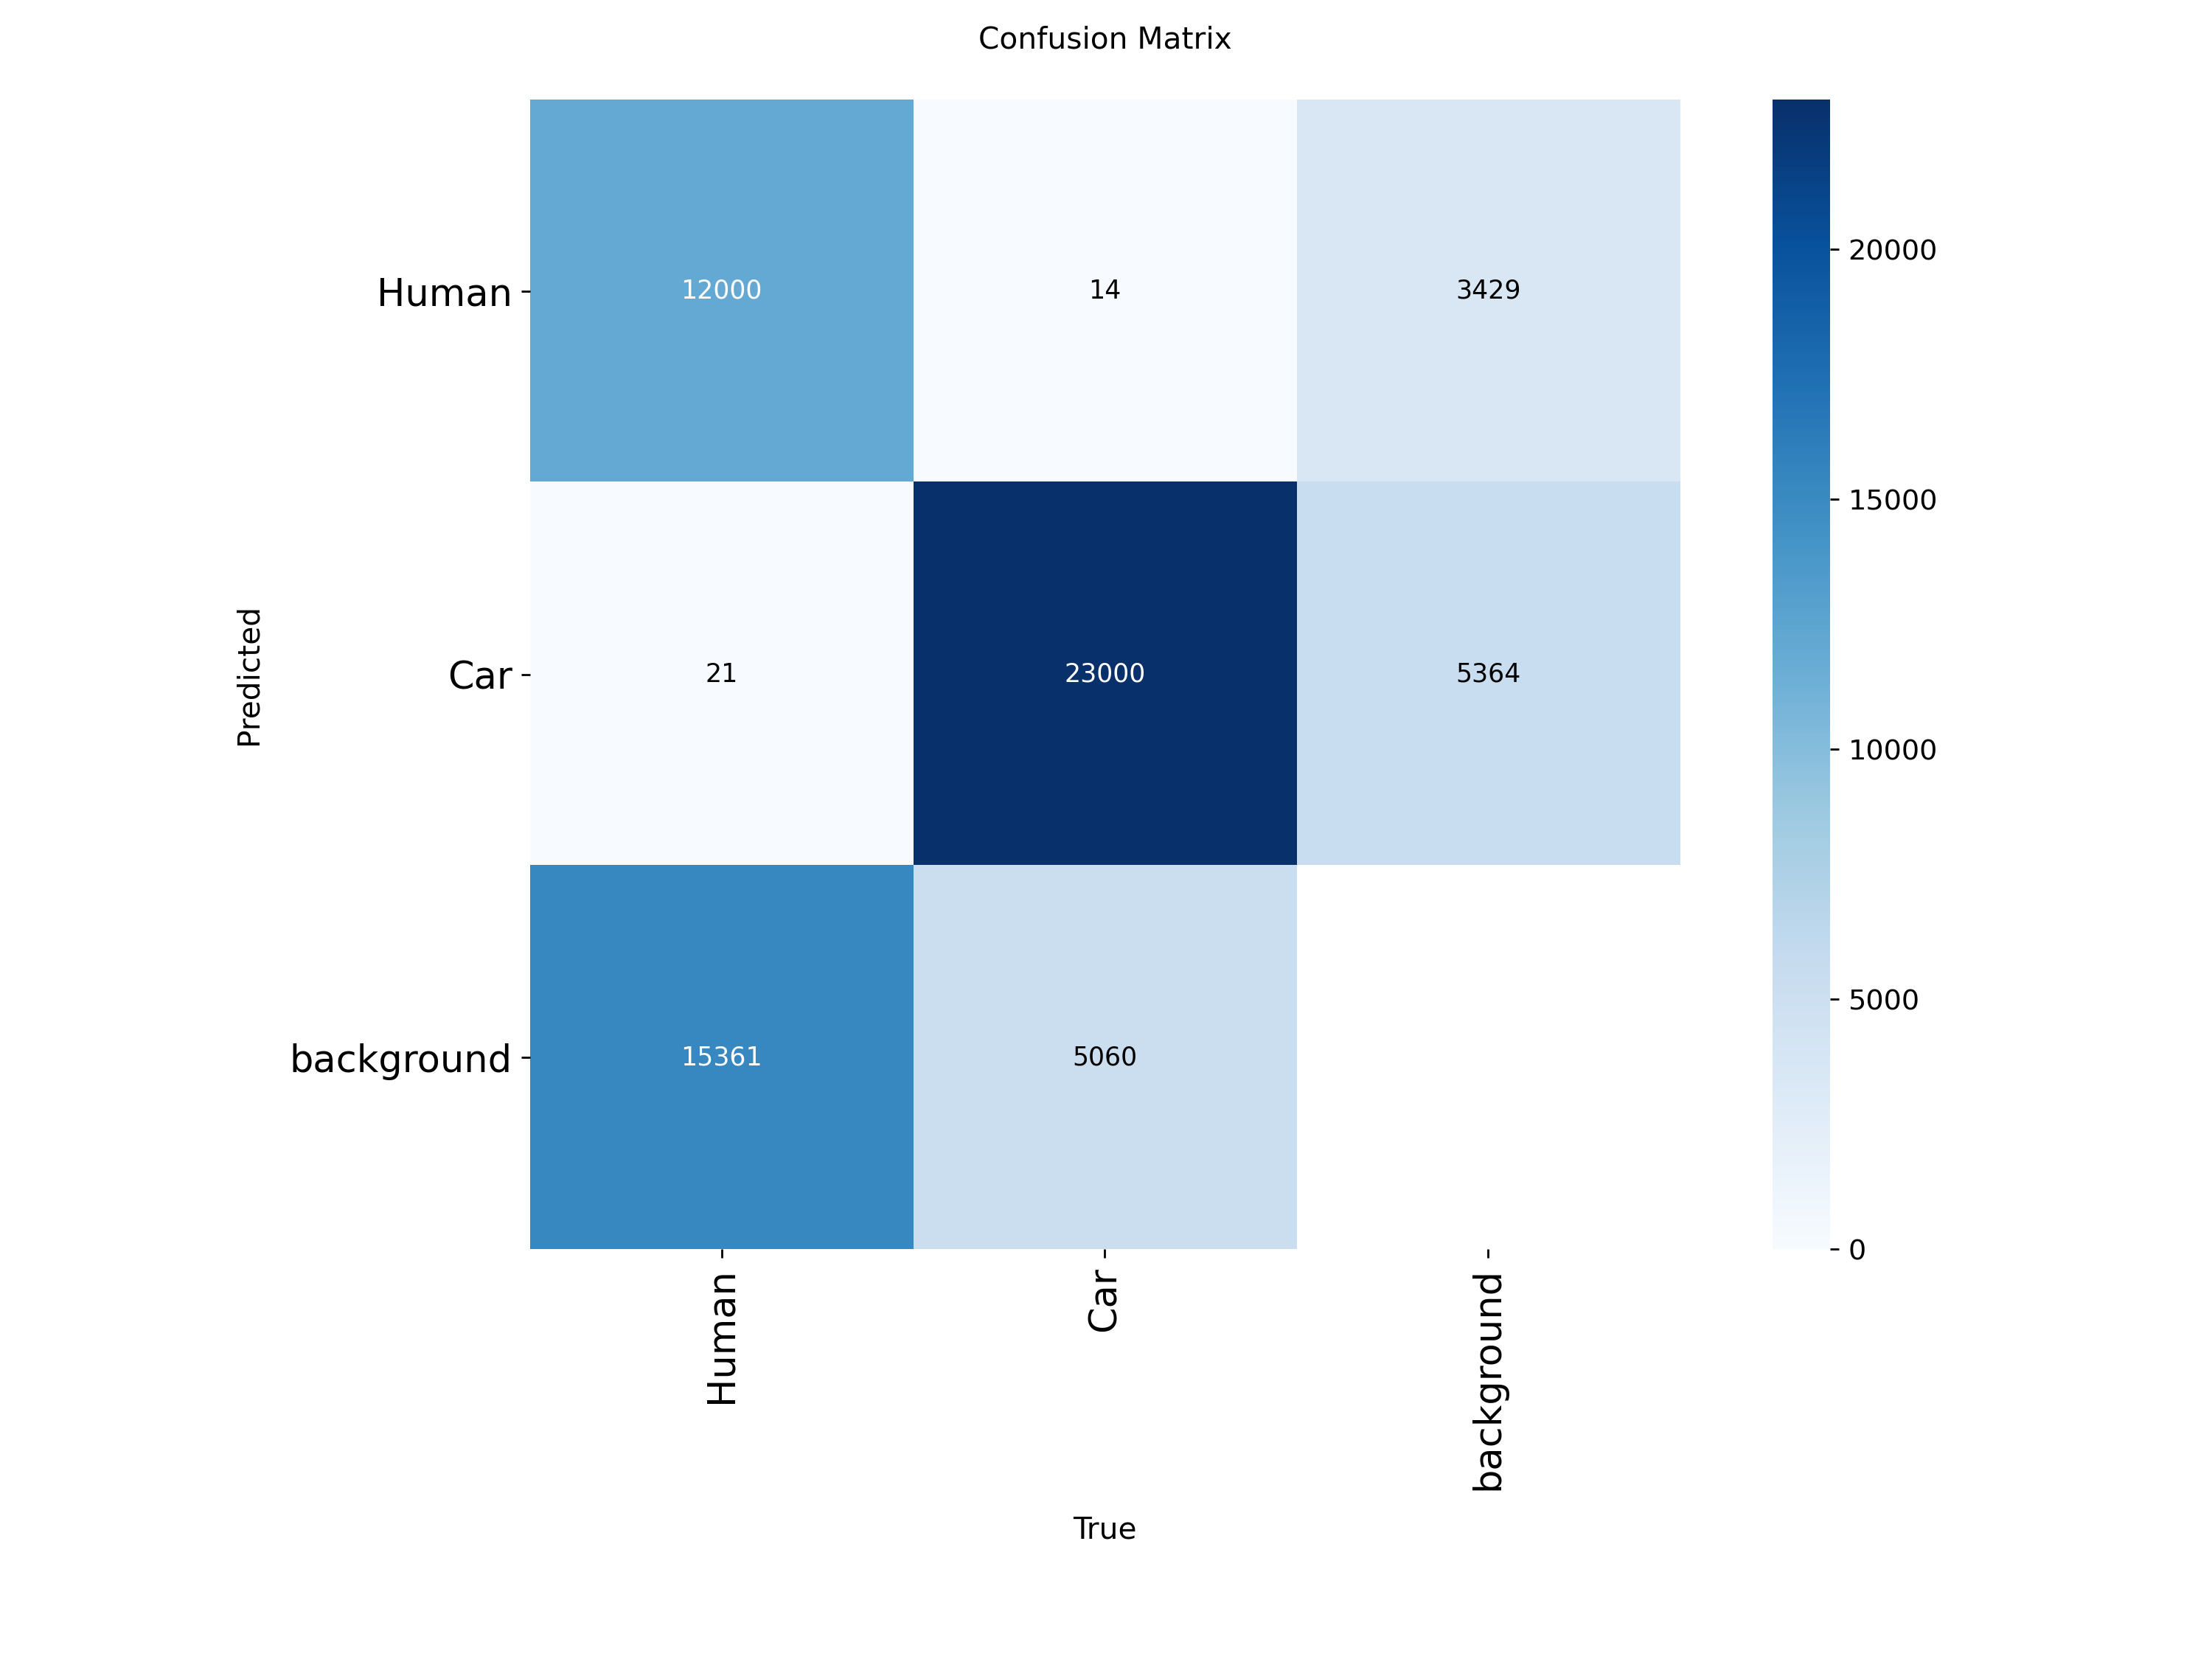


confusion_matrix_normalized.png:


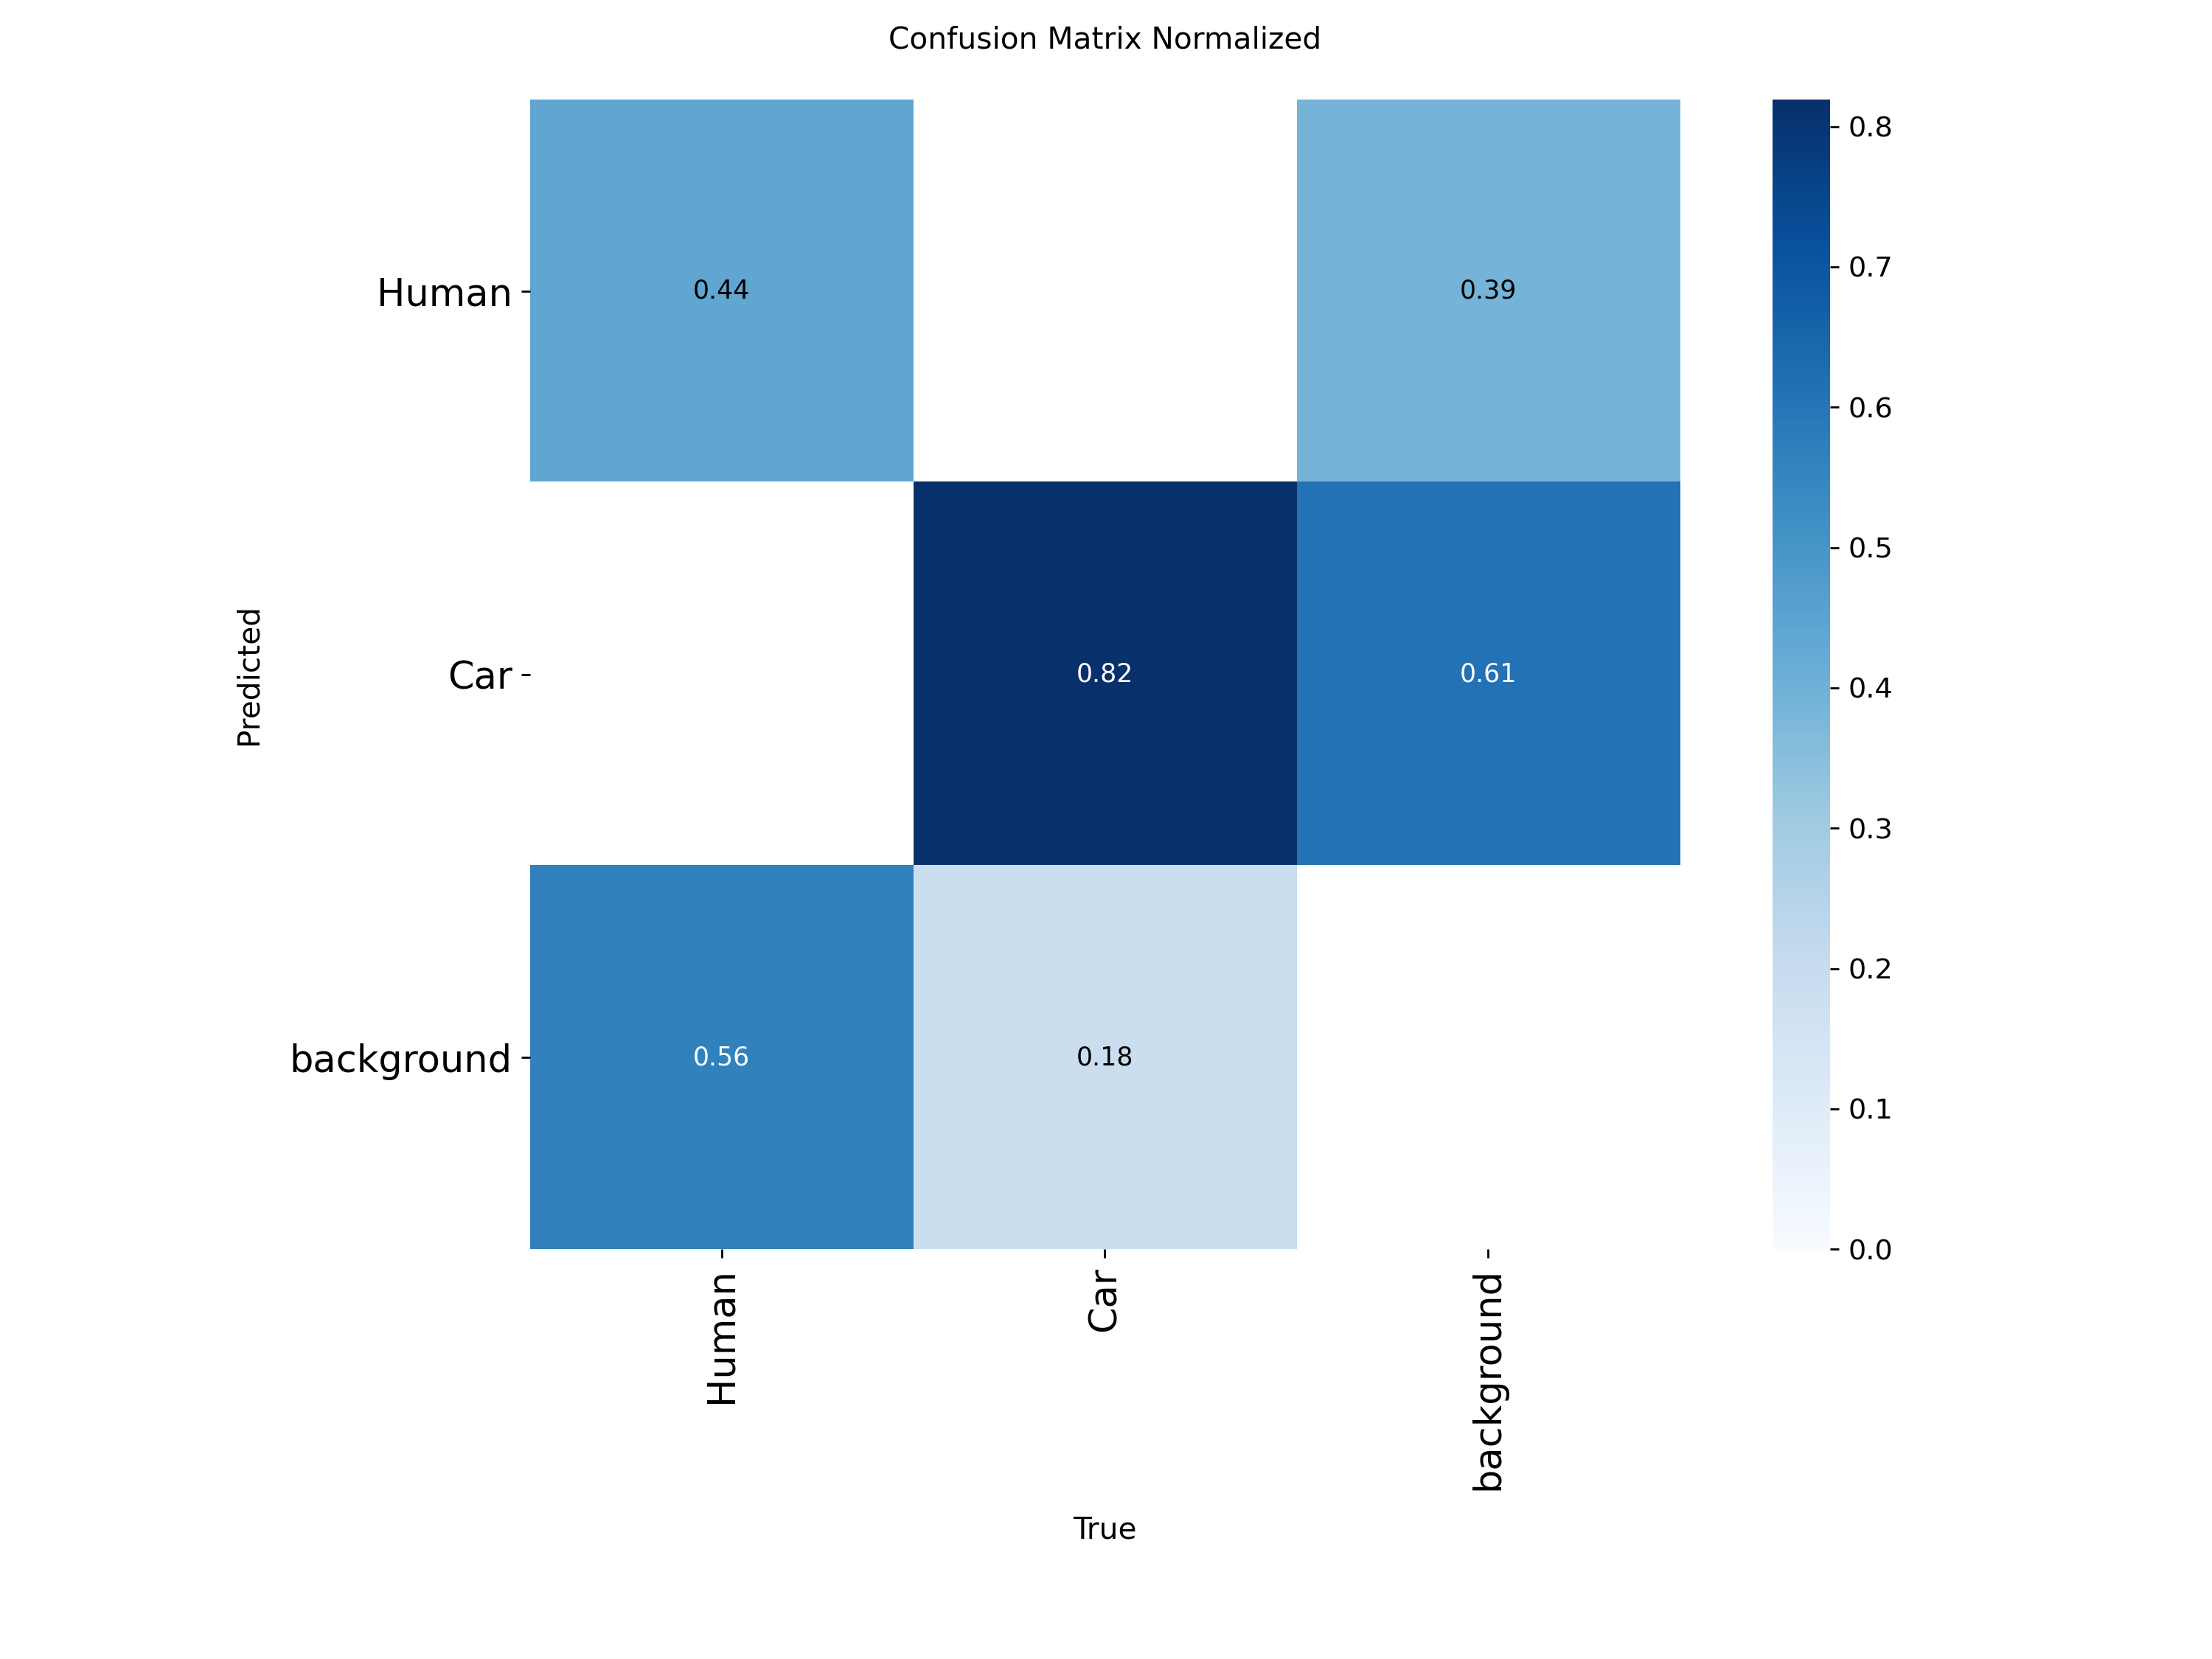


TEST SET METRICS:
  mAP@0.5:     0.5696
  mAP@0.5:0.95: 0.3211

  Human:
    AP@0.5:     0.3761
    AP@0.5:0.95: 0.1591

  Car:
    AP@0.5:     0.7632
    AP@0.5:0.95: 0.4830
  Precision:    0.7716
  Recall:       0.6149
    Precision:  0.8038
    Recall:     0.8127


In [10]:
best_model_path = '/kaggle/working/runs/p2_head_1280/weights/best.pt'

CLASS_NAMES_NEW = {0: "Human", 1: "Car"}

model_infer = YOLO(best_model_path)

eval_results = model_infer.val(
    data=DATA_YAML,
    split='test',
    imgsz=1280,
    batch=2,
    conf=0.25,
    iou=0.45,
    plots=True,
    verbose=True,
    project='/kaggle/working/runs',
    name='test_evaluation',
    exist_ok=True,
)

# Display evaluation plots
eval_dir = '/kaggle/working/runs/test_evaluation'
for plot in ['confusion_matrix.png', 'confusion_matrix_normalized.png',
             'P_curve.png', 'R_curve.png', 'F1_curve.png', 'PR_curve.png']:
    plot_path = os.path.join(eval_dir, plot)
    if os.path.exists(plot_path):
        print(f"\n{plot}:")
        from IPython.display import Image as IPImage, display
        display(IPImage(filename=plot_path, width=700))

print("\nTEST SET METRICS:")
print(f"  mAP@0.5:     {eval_results.box.map50:.4f}")
print(f"  mAP@0.5:0.95: {eval_results.box.map:.4f}")

# Per-class metrics
if hasattr(eval_results.box, 'ap_class_index'):
    for i, cls_idx in enumerate(eval_results.box.ap_class_index):
        cls_name = CLASS_NAMES_NEW.get(cls_idx, f'cls_{cls_idx}')
        print(f"\n  {cls_name}:")
        print(f"    AP@0.5:     {eval_results.box.ap50[i]:.4f}")
        print(f"    AP@0.5:0.95: {eval_results.box.ap[i]:.4f}")

print(f"  Precision:    {eval_results.box.mp:.4f}")
print(f"  Recall:       {eval_results.box.mr:.4f}")
print(f"    Precision:  {eval_results.box.p[i]:.4f}")
print(f"    Recall:     {eval_results.box.r[i]:.4f}")